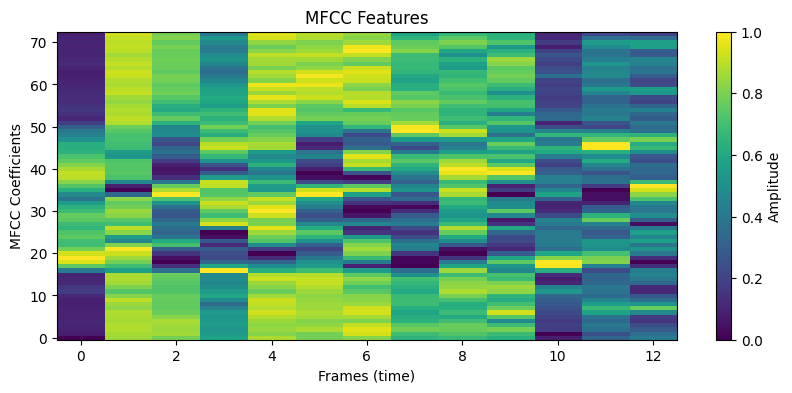

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Load fitur dari file .npy
mfcc = np.load("../../Dataset/Acoustic_Features/eval/MFCC/1001_DFA_DIS_XX_mfcc.npy")

plt.figure(figsize=(10, 4))
plt.imshow(mfcc, aspect='auto', origin='lower', cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label="Amplitude")
plt.title("MFCC Features")
plt.xlabel("Frames (time)")
plt.ylabel("MFCC Coefficients")
plt.show()


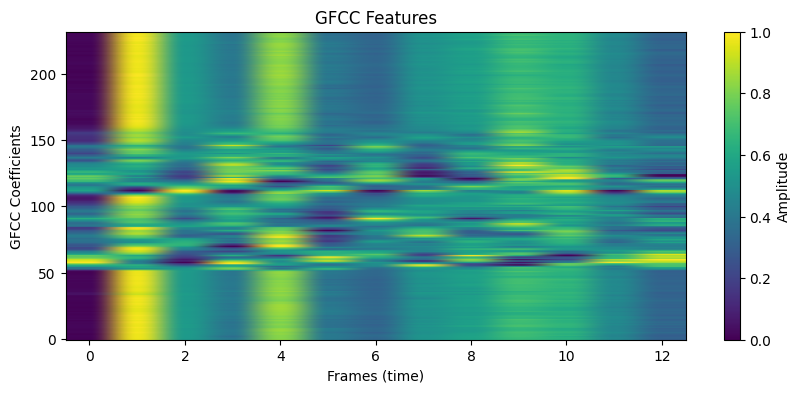

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Load fitur dari file .npy
gfcc = np.load("../../Dataset/Acoustic_Features/eval/GFCC/1001_DFA_DIS_XX_gfcc.npy")

plt.figure(figsize=(10, 4))
plt.imshow(gfcc, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label="Amplitude")
plt.title("GFCC Features")
plt.xlabel("Frames (time)")
plt.ylabel("GFCC Coefficients")
plt.show()

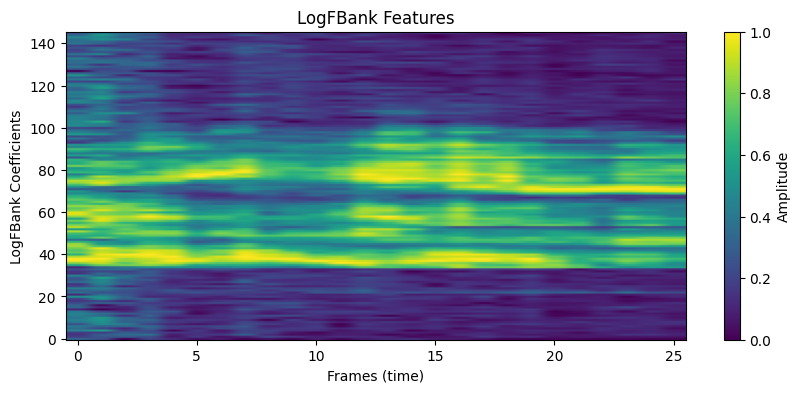

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Load fitur dari file .npy
logfbank = np.load("../../Dataset/Acoustic_Features/eval/LogFBank/1001_DFA_DIS_XX_logfbank.npy")

plt.figure(figsize=(10, 4))
plt.imshow(logfbank, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label="Amplitude")
plt.title("LogFBank Features")
plt.xlabel("Frames (time)")
plt.ylabel("LogFBank Coefficients")
plt.show()


TypeError: Invalid shape (128,) for image data

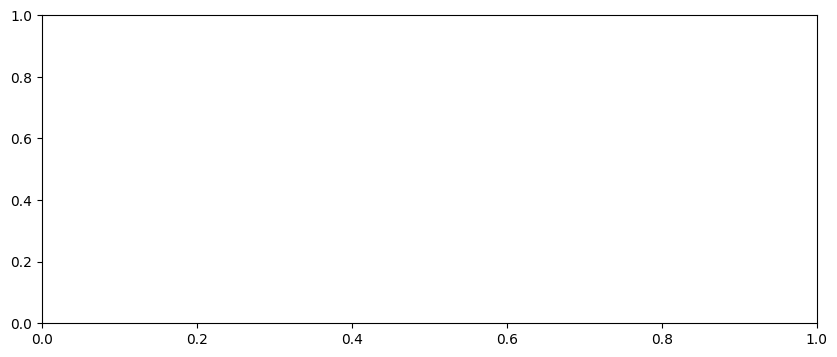

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Load fitur dari file .npy
lstm = np.load("Dataset/LSTM_Features/train/1001_DFA_ANG_XX_summary.npy")

plt.figure(figsize=(10, 4))
plt.imshow(lstm, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label="Amplitude")
plt.title("GFCC Features")
plt.xlabel("Frames (time)")
plt.ylabel("GFCC Coefficients")
plt.show()


In [ ]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ---------------- Config ----------------
summary_dir = "Dataset/Temporal_Features/test/MFCC"  # ganti sesuai fitur & split
csv_path = "Dataset/CSV/test_split_stress.csv"       # labelnya

# ---------------- Load Label ----------------
df = pd.read_csv(csv_path)  # isi: filename, actor, sentence, emotion, pitch, stress
label_map = {lab: idx for idx, lab in enumerate(df["emotion"].unique())}  # mapping label ke angka

X, y = [], []
for i, row in df.iterrows():
    fname = row["filename"]
    emotion = row["emotion"]

    summary_path = os.path.join(summary_dir, f"{fname}_summary.npy")
    if os.path.exists(summary_path):
        feat = np.load(summary_path)
        X.append(feat)
        y.append(label_map[emotion])

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)  # (N, hidden_dim)

# ---------------- PCA ----------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6, 5))
for lab, idx in label_map.items():
    plt.scatter(X_pca[y == idx, 0], X_pca[y == idx, 1], label=lab, alpha=0.7)
plt.legend()
plt.title("PCA Visualization of LSTM Summary Features")
plt.show()

# ---------------- t-SNE ----------------
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(6, 5))
for lab, idx in label_map.items():
    plt.scatter(X_tsne[y == idx, 0], X_tsne[y == idx, 1], label=lab, alpha=0.7)
plt.legend()
plt.title("t-SNE Visualization of LSTM Summary Features")
plt.show()


Working dir: C:\personal\coding\hadi_skripsi\Scripts\Visualizer
Resolved csv_path: C:\Personal\coding\hadi_skripsi\Dataset\CSV\test_split_stress.csv
Found features: 0 / 744 rows
Found files: 0
Missing files: 744


FileNotFoundError: Tidak ditemukan fitur summary (.npy). Periksa summary_dir dan nama berkas pada CSV.

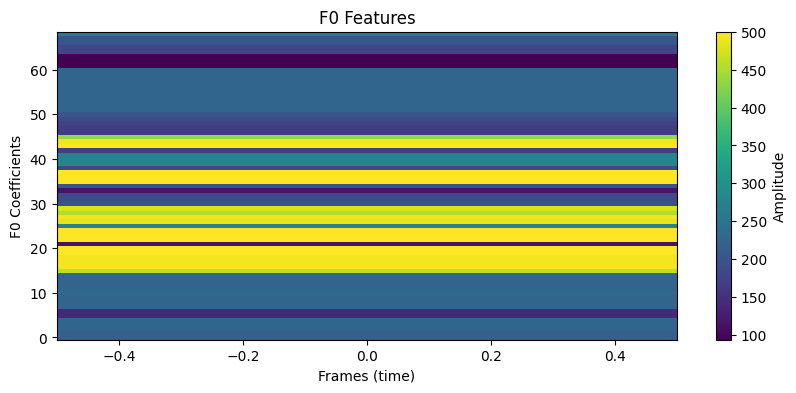

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Load fitur dari file .npy
f0 = np.load("../../Dataset/Acoustic_Features/eval/F0/1001_DFA_DIS_XX_f0.npy")
# mfcc = np.load("../../Dataset/Acoustic_Features/eval/MFCC/1001_DFA_DIS_XX_mfcc.npy")

plt.figure(figsize=(10, 4))
plt.imshow(f0, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label="Amplitude")
plt.title("F0 Features")
plt.xlabel("Frames (time)")
plt.ylabel("F0 Coefficients")
plt.show()
